Project: /gemma/_project.yaml
Book: /gemma/_book.yaml

<link rel="stylesheet" href="/site-assets/css/style.css">
<link rel="stylesheet" href="/site-assets/css/gemma.css">
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=Google+Symbols:opsz,wght,FILL,GRAD@20..48,100..700,0..1,-50..200" />

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://ai.google.dev/gemma/docs/capabilities/thinking"><img src="https://ai.google.dev/static/site-assets/images/docs/notebook-site-button.png" height="32" width="32" />View on ai.google.dev</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google/generative-ai-docs/blob/main/site/en/gemma/docs/capabilities/thinking.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/google/generative-ai-docs/blob/main/site/en/gemma/docs/capabilities/thinking.ipynb"><img src="https://www.kaggle.com/static/images/logos/kaggle-logo-transparent-300.png" height="32" width="70"/>Run in Kaggle</a>
  </td>
  <td>
    <a target="_blank" href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fgoogle%2Fgenerative-ai-docs%2Fmain%2Fsite%2Fen%2Fgemma%2Fdocs%2Fcapabilities%2Fthinking.ipynb"><img src="https://ai.google.dev/images/cloud-icon.svg" width="40" />Open in Vertex AI</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google/generative-ai-docs/blob/main/site/en/gemma/docs/capabilities/thinking.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

# Thinking mode in Gemma

Gemma is a family of lightweight, state-of-the-art open models built from the same research and technology used to create the [Gemini](https://deepmind.google/technologies/gemini/#introduction) models. Gemma 4 is designed to be the world's most efficient open-weight model family.

<h2><font color=orange>⚠️ EARLY ACCESS: This is not the final model behaviour or example. They are subject to change and further improvements.</font></h2>

## Setup

Before starting this tutorial, complete the following steps:

- Get access to Gemma 4 by logging into [Hugging Face](https://huggingface.co/collections/google/gemma-4) and selecting Acknowledge license for a FunctionGemma model.
- Generate a Hugging Face [Access Token](https://huggingface.co/docs/hub/en/security-tokens#how-to-manage-user-access-token) and add it to your Colab environment.

This notebook will run on T4 GPU.

## Install Python packages

Install the Hugging Face libraries required for running the Gemma model and making requests.

In [ ]:
# Install PyTorch & other libraries
!pip install torch

# Install the transformers library
!pip install transformers

<h2><font color=red>REMOVE AFTER LAUNCH</font></h2>
Temporary using to download the internal wheel

In [ ]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
!hf auth login --token $HF_TOKEN
#!hf download --local-dir ./gemma-4-eap-extras --repo-type dataset gg-hf-gg/gemma-4-eap-extras --revision 5d743c7
!hf download --local-dir ./gemma-4-eap-extras --repo-type dataset gg-hf-gg/gemma-4-eap-extras
!pip install ./gemma-4-eap-extras/transformers-5.3.0.dev0-py3-none-any.whl
!sha256sum ./gemma-4-eap-extras/transformers-5.3.0.dev0-py3-none-any.whl


The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `colab` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Fetching 10 files: 100% 10/10 [00:02<00:00,  3.55it/s]
Download complete: : 1.16GB [00:02, 752MB/s]              /content/gemma-4-eap-extras
Download complete: : 1.16GB [00:02, 408MB/s]
Processing ./gemma-4-eap-extras/transformers-5.3.0.dev0-py3-none-any.whl
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
48fcdfbe32bdc327f54222e9467329

After you have accepted the license, you need a valid Hugging Face Token to access the model.

In [ ]:
# Login into Hugging Face Hub
from huggingface_hub import login
login()

## Load Model

Use the `transformers` libraries to create an instance of a `processor` and `model` using the `AutoProcessor` and `AutoModelForImageTextToText` classes as shown in the following code example:

In [ ]:
MODEL_ID = "gg-hf-gg/gemma-4-e2b-it" # @param ["gg-hf-gg/gemma-4-e2b-it","gg-hf-gg/gemma-4-e4b-it"] {"allow-input":true}

from transformers import AutoProcessor, AutoModelForImageTextToText

model = AutoModelForImageTextToText.from_pretrained(MODEL_ID, dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=False)

[ERROR] `vision_output_length` is part of Gemma4Model.get_image_features's signature, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.12/dist-packages/transformers/models/gemma4/modeling_gemma4.py.
[ERROR] `vision_output_length` is part of Gemma4ForConditionalGeneration.forward's signature, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.12/dist-packages/transformers/models/gemma4/modeling_gemma4.py.


Loading weights:   0%|          | 0/2023 [00:00<?, ?it/s]

## A single text inference with Thinking

In [ ]:
from transformers import TextStreamer

message = [
    {
        "role": "user", "content": "What is the water formula?"
    }
]

text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True, enable_thinking=True)
inputs = processor(text=text, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]

streamer = TextStreamer(processor)
outputs = model.generate(**inputs, streamer=streamer, max_new_tokens=1024)

<bos><|turn>system
<|think|><turn|>
<|turn>user
What is the water formula?<turn|>
<|turn>model
<|channel>thought
Thinking Process:

1.  **Analyze the Request:** The user is asking "What is the water formula?"
2.  **Interpret Ambiguity:** "Water formula" is highly ambiguous. It could refer to:
    *   **Chemical Formula:** $\text{H}_2\text{O}$ (the molecular formula).
    *   **Scientific/Chemical Properties/Structure:** Its polarity, hydrogen bonding, etc.
    *   **Biological/Hydrological Formula:** The water cycle, the formula for water in living things, etc.
    *   **A Specific Context:** A formula in chemistry, physics, or a specific puzzle/game.
3.  **Determine the Most Likely Intent:** In a general knowledge context, when someone asks for the "formula" of water, they almost always mean the chemical formula.
4.  **Formulate the Primary Answer (Chemical Formula):** State the molecular formula clearly.
5.  **Provide Context (The Structure/Bonding):** Explain *why* the formula is $\

In [ ]:
from transformers.models.gemma4.utils_gemma4 import parse_thinking_output

response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
result = parse_thinking_output(response)

if result["thinking"]:
  print("\n=== Thoughts ===\n")
  print(result['thinking'])
  print("\n=== Answer ===\n")
  print(result['answer'])
else:
  print(f"=== Response (no thinking delimiters) ===\n{response}...")



=== Thoughts ===

Thinking Process:

1.  **Analyze the Request:** The user is asking "What is the water formula?"
2.  **Interpret Ambiguity:** "Water formula" is highly ambiguous. It could refer to:
    *   **Chemical Formula:** $\text{H}_2\text{O}$ (the molecular formula).
    *   **Scientific/Chemical Properties/Structure:** Its polarity, hydrogen bonding, etc.
    *   **Biological/Hydrological Formula:** The water cycle, the formula for water in living things, etc.
    *   **A Specific Context:** A formula in chemistry, physics, or a specific puzzle/game.
3.  **Determine the Most Likely Intent:** In a general knowledge context, when someone asks for the "formula" of water, they almost always mean the chemical formula.
4.  **Formulate the Primary Answer (Chemical Formula):** State the molecular formula clearly.
5.  **Provide Context (The Structure/Bonding):** Explain *why* the formula is $\text{H}_2\text{O}$ (covalent bonding, polarity, hydrogen bonds). This adds value beyond just t

## A single image inference

=== Downloaded image ===


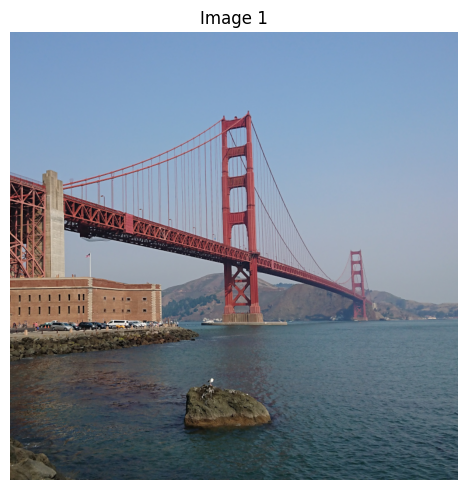

=== Thoughts ===

Here's a thinking process to arrive at the suggested answer:

1.  **Analyze the Image:**
    *   **Dominant Structure:** The most prominent feature is a massive suspension bridge with distinctive red steel towers and cables.
    *   **Identify the Bridge:** Based on its appearance (iconic suspension design, red color, setting over water with hills/mountains), this is clearly the Golden Gate Bridge.
    *   **Foreground/Water:** There is water in the foreground. A rocky outcrop is visible in the immediate foreground.
    *   **Shoreline/Land:** There is a large structure (a breakwater/pier/building) on the left side near the base of the bridge. Hills/mountains are visible in the background.
    *   **Atmosphere/Lighting:** The lighting is bright, suggesting a sunny day. The sky is clear and pale blue/hazy.

2.  **Synthesize the Subject Matter (What is it?):**
    *   The core subject is the Golden Gate Bridge and the surrounding San Francisco Bay/water.

3.  **Refine t

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

prompt = "What is shown in this image?"
image_url = "https://raw.githubusercontent.com/google-gemini/gemma-cookbook/refs/heads/main/Demos/sample-data/GoldenGate.png"

# download image
!wget -q {image_url} -O image.png
image = Image.open("image.png")

# Display all images
print("=== Downloaded image ===")
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(image)
ax.set_title("Image 1")
ax.axis("off")
plt.tight_layout()
plt.show()

message = [
    {
        "role": "user", "content": [
          {"type": "image"},
          {"type": "text", "text": prompt}
        ]
    }
]

text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True, enable_thinking=True)
inputs = processor(text=text, images=image, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]

outputs = model.generate(**inputs, max_new_tokens=1024)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
result = parse_thinking_output(response)

if result["thinking"]:
    print("=== Thoughts ===\n")
    print(result['thinking'])
    print("\n=== Answer ===\n")
    print(result['answer'])
else:
    print(f"=== Response (no thinking delimiters) ===\n{response}...")

## Summary and next steps

Check out other resources.

- [Prompt and system instructions](/gemma/docs/core/prompt-formatting-gemma4)
- [Function calling](/gemma/docs/capabilities/function-calling-gemma4)
- [Run Gemma overview](/gemma/docs/run)